# Partición de Grafos
## MA2015 - Diseño de Algoritmos Bioinspirados

Viviana Carrizales Luna (A01286191) & Steffany Mishell Lara Muy (A00838589)
*Instituto Tecnológico y de Estudios Superiores de Monterrey (ITESM)*

**Resumen**
El presente proyecto tiene como finalidad desarrollar un algoritmo bioinspirado de partición de grafos para encontrar la solución óptima al problema de 16 grafos propuesto en clase.

### 1. Planteamiento del Problema

In [144]:
import pulp, time, random
import matplotlib.pyplot as plt

In [145]:
# Grafo: 16 nodos, 28 aristas
V = list(range(1,17))
E = [(1,2),(1,9),(1,14),(2,3),(2,5),(3,4),(3,5),
     (3,6),(3,7),(4,6),(5,7),(5,9),(5,10),(6,7),
     (6,8),(7,8),(7,11),(8,11),(9,10),(9,13),(9,14),
     (10,11),(10,12),(12,16),(13,15),(13,16),(14,15),(15,16)
     ]
print(E)
def corte(ind): 
    return sum(1 for u,v in E if ind[u-1] != ind[v-1])

def aristas_corte(ind):
    return [(u,v,ind[u-1],ind[v-1]) for u,v in E if ind[u-1] != ind[v-1]]

[(1, 2), (1, 9), (1, 14), (2, 3), (2, 5), (3, 4), (3, 5), (3, 6), (3, 7), (4, 6), (5, 7), (5, 9), (5, 10), (6, 7), (6, 8), (7, 8), (7, 11), (8, 11), (9, 10), (9, 13), (9, 14), (10, 11), (10, 12), (12, 16), (13, 15), (13, 16), (14, 15), (15, 16)]


### 2. Solución Exacta

In [146]:
def exacto(k):
    t0 = time.time()
    prob = pulp.LpProblem("Particion", pulp.LpMinimize)
    # x[i,g] = 1 si nodo i en grupo g
    x = {(i,g): pulp.LpVariable(f"x_{i}_{g}", cat='Binary') for i in V for g in range(k)}
    y = {(u,v): pulp.LpVariable(f"y_{u}_{v}", 0, 1) for u,v in E}
    
    # Cada nodo en exactamente un grupo
    for i in V: prob += pulp.lpSum(x[i,g] for g in range(k)) == 1
    # Balance: cada grupo tiene ~n/k nodos
    for g in range(k): 
        prob += pulp.lpSum(x[i,g] for i in V) >= len(V)//k
        prob += pulp.lpSum(x[i,g] for i in V) <= (len(V)+k-1)//k
    # Linealizar corte
    for u,v in E:
        for g in range(k): prob += y[(u,v)] >= x[u,g] - x[v,g]
        for g in range(k): prob += y[(u,v)] >= x[v,g] - x[u,g]
    prob += pulp.lpSum(y[(u,v)] for u,v in E)
    
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    t = time.time() - t0
    
    # Extraer solución
    ind = [next(g for g in range(k) if pulp.value(x[i,g])==1) for i in V]
    return ind, corte(ind), t


### 3. Solución con Algoritmo Genético

In [147]:
def ag(k, pop_size=50, gens=100, p_cruz=0.8, p_mut=0.1, tourn=3, pen=100, estancamiento=15):
    def fitness(ind):
        tam = [ind.count(g) for g in range(k)]
        return -corte(ind) - pen * sum(abs(t - len(V)/k) for t in tam)
    
    def init():
        asig = [g for g in range(k) for _ in range((len(V)+k-1)//k)][:len(V)]
        random.shuffle(asig)
        return asig
    
    def selec(pop, fits):
        return pop[max(random.sample(range(len(pop)), tourn), key=lambda i: fits[i])][:]
    
    def cruce(p1, p2):
        pt = random.randint(1, len(p1)-1)
        return p1[:pt]+p2[pt:], p2[:pt]+p1[pt:]
    
    def mutar(ind):
        return [random.randint(0,k-1) if random.random()<p_mut else g for g in ind]
    
    def reparar(ind):
        for _ in range(len(V)):
            tam = [ind.count(g) for g in range(k)]
            gmax, gmin = max(range(k),key=lambda g:tam[g]), min(range(k),key=lambda g:tam[g])
            if tam[gmax]-tam[gmin] <= 1: break
            nodos = [i for i,g in enumerate(ind) if g==gmax]
            if nodos: ind[random.choice(nodos)] = gmin
        return ind
    
    t0 = time.time()
    pop = [init() for _ in range(pop_size)]
    hist_corte, hist_tiempo = [], []
    hist_mejor, hist_prom, hist_peor = [], [], []
    mejor_global = float('inf')
    sin_mejora = 0
    
    for gen in range(gens):
        fits = [fitness(ind) for ind in pop]
        cortes = [corte(ind) for ind in pop]
        mejor = pop[max(range(pop_size), key=lambda i: fits[i])]
        c_mejor = corte(mejor)
        hist_corte.append(c_mejor)
        hist_tiempo.append(time.time()-t0)
        hist_mejor.append(min(cortes))  # Mejor = menor corte
        hist_prom.append(sum(cortes)/len(cortes))
        hist_peor.append(max(cortes))  # Peor = mayor corte
        
        # Mostrar grupos y costo en cada iteración
        grupos = {g: [V[i] for i,x in enumerate(mejor) if x==g] for g in range(k)}
        print(f"Gen {gen:3d} | Costo(corte)={c_mejor:2d} | ", end="")
        for g in range(k): print(f"G{g}:{grupos[g]}", end=" ")
        
        # Criterio de paro por estancamiento
        if c_mejor < mejor_global:
            mejor_global = c_mejor
            sin_mejora = 0
            print("← mejora!")
        else:
            sin_mejora += 1
            print()
        
        if sin_mejora >= estancamiento:
            print(f"\n*** PARO: {estancamiento} generaciones sin mejora ***")
            break
        
        nueva = [mejor[:]]
        while len(nueva) < pop_size:
            p1, p2 = selec(pop,fits), selec(pop,fits)
            h1, h2 = cruce(p1,p2) if random.random()<p_cruz else (p1[:],p2[:])
            nueva.extend([reparar(mutar(h1)), reparar(mutar(h2))])
        pop = nueva[:pop_size]
    
    fits = [fitness(ind) for ind in pop]
    mejor = pop[max(range(pop_size), key=lambda i: fits[i])]
    return mejor, corte(mejor), time.time()-t0, hist_corte, hist_tiempo, hist_mejor, hist_prom, hist_peor


In [148]:

def mostrar(titulo, ind, k, c, t):
    grupos = {g: [V[i] for i,x in enumerate(ind) if x==g] for g in range(k)}
    print(f"\n{'='*50}\n{titulo}\n{'='*50}")
    print(f"Corte: {c}, Tiempo: {t:.4f}s")
    for g, nodos in grupos.items(): print(f"  Grupo {g}: {nodos}")
    print(f"Aristas de corte: {aristas_corte(ind)}")


4. Comparación


############################################################
### K = 2 GRUPOS ###
############################################################

EXACTO (PuLP) K=2
Corte: 4, Tiempo: 0.1625s
  Grupo 0: [2, 3, 4, 5, 6, 7, 8, 11]
  Grupo 1: [1, 9, 10, 12, 13, 14, 15, 16]
Aristas de corte: [(1, 2, 1, 0), (5, 9, 0, 1), (5, 10, 0, 1), (10, 11, 1, 0)]
Gen   0 | Costo(corte)= 8 | G0:[1, 5, 9, 10, 12, 13, 14, 15] G1:[2, 3, 4, 6, 7, 8, 11, 16] ← mejora!
Gen   1 | Costo(corte)= 8 | G0:[1, 5, 9, 10, 12, 13, 14, 15] G1:[2, 3, 4, 6, 7, 8, 11, 16] 
Gen   2 | Costo(corte)= 6 | G0:[1, 4, 9, 12, 13, 14, 15, 16] G1:[2, 3, 5, 6, 7, 8, 10, 11] ← mejora!
Gen   3 | Costo(corte)= 6 | G0:[1, 4, 9, 12, 13, 14, 15, 16] G1:[2, 3, 5, 6, 7, 8, 10, 11] 
Gen   4 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 15, 16] G1:[3, 4, 5, 6, 7, 8, 10, 11] ← mejora!
Gen   5 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 15, 16] G1:[3, 4, 5, 6, 7, 8, 10, 11] 
Gen   6 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 15, 16] G1:[3, 4, 5, 6

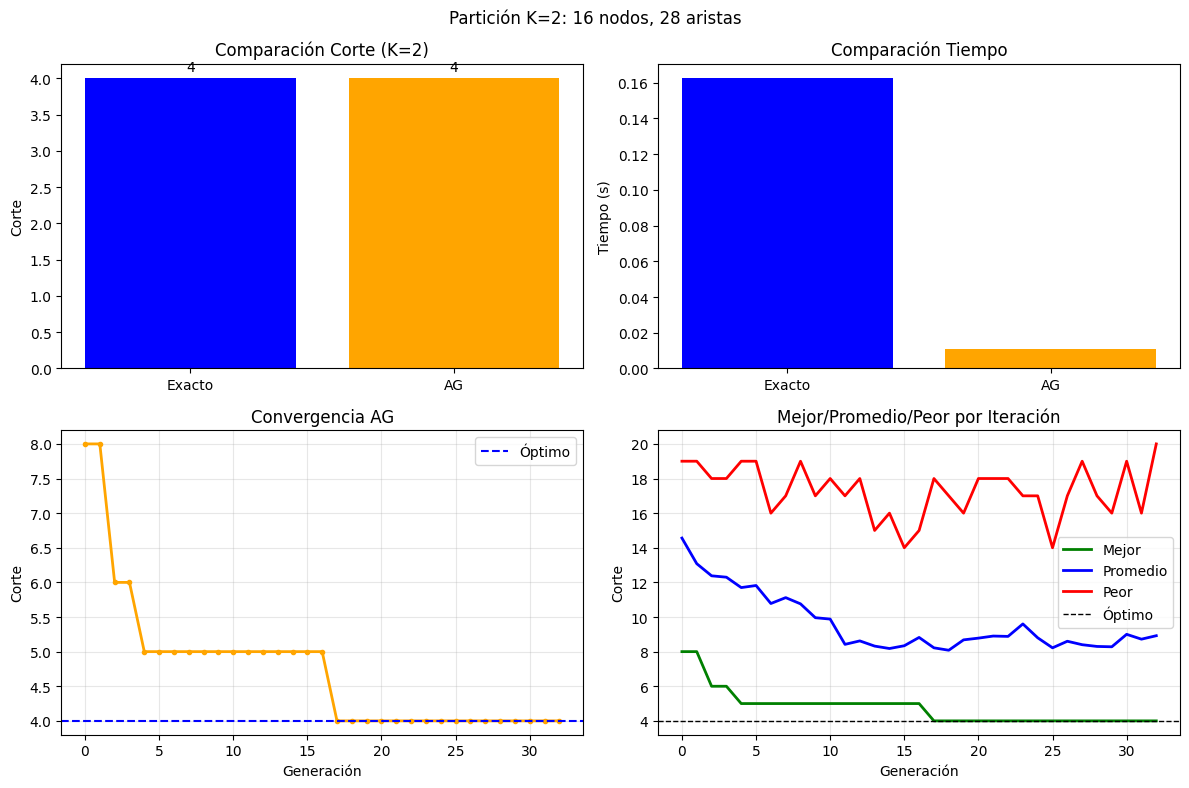

In [149]:

# === EJECUCIÓN ===
if __name__ == "__main__":
    for K in [2]:
        print(f"\n{'#'*60}\n### K = {K} GRUPOS ###\n{'#'*60}")
        random.seed(42)
        
        # Exacto
        ind_ex, c_ex, t_ex = exacto(K)
        mostrar(f"EXACTO (PuLP) K={K}", ind_ex, K, c_ex, t_ex)
        
        # AG
        ind_ag, c_ag, t_ag, hist_c, hist_t, hist_mejor, hist_prom, hist_peor = ag(K)
        mostrar(f"AG K={K}", ind_ag, K, c_ag, t_ag)
        
        # Tabla comparativa
        print(f"\n{'Método':<15} {'Corte':<8} {'Tiempo(s)':<10}")
        print(f"{'-'*35}")
        print(f"{'Exacto':<15} {c_ex:<8} {t_ex:<10.4f}")
        print(f"{'AG':<15} {c_ag:<8} {t_ag:<10.4f}")
        
        # Gráficas
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        
        # Barras comparativas
        axes[0,0].bar(['Exacto','AG'], [c_ex,c_ag], color=['blue','orange'])
        axes[0,0].set_ylabel('Corte'); axes[0,0].set_title(f'Comparación Corte (K={K})')
        for i,v in enumerate([c_ex,c_ag]): axes[0,0].text(i,v+0.1,str(v),ha='center')
        
        axes[0,1].bar(['Exacto','AG'], [t_ex,t_ag], color=['blue','orange'])
        axes[0,1].set_ylabel('Tiempo (s)'); axes[0,1].set_title('Comparación Tiempo')
        
        # Convergencia AG
        axes[1,0].plot(hist_c, 'o-', color='orange', lw=2, ms=3)
        axes[1,0].axhline(c_ex, color='blue', ls='--', label='Óptimo')
        axes[1,0].set_xlabel('Generación'); axes[1,0].set_ylabel('Corte')
        axes[1,0].set_title('Convergencia AG'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)
        
        # Mejor, Promedio, Peor por iteración
        gens = range(len(hist_mejor))
        axes[1,1].plot(gens, hist_mejor, 'g-', lw=2, label='Mejor')
        axes[1,1].plot(gens, hist_prom, 'b-', lw=2, label='Promedio')
        axes[1,1].plot(gens, hist_peor, 'r-', lw=2, label='Peor')
        axes[1,1].axhline(c_ex, color='black', ls='--', lw=1, label='Óptimo')
        axes[1,1].set_xlabel('Generación'); axes[1,1].set_ylabel('Corte')
        axes[1,1].set_title('Mejor/Promedio/Peor por Iteración')
        axes[1,1].legend(); axes[1,1].grid(alpha=0.3)
        
        plt.suptitle(f'Partición K={K}: {len(V)} nodos, {len(E)} aristas')
        plt.tight_layout(); plt.show()

Gen   0 | Costo(corte)= 8 | G0:[1, 5, 9, 10, 12, 13, 14, 15] G1:[2, 3, 4, 6, 7, 8, 11, 16] ← mejora!
Gen   1 | Costo(corte)= 8 | G0:[1, 5, 9, 10, 12, 13, 14, 15] G1:[2, 3, 4, 6, 7, 8, 11, 16] 
Gen   2 | Costo(corte)= 6 | G0:[1, 4, 9, 12, 13, 14, 15, 16] G1:[2, 3, 5, 6, 7, 8, 10, 11] ← mejora!
Gen   3 | Costo(corte)= 6 | G0:[1, 4, 9, 12, 13, 14, 15, 16] G1:[2, 3, 5, 6, 7, 8, 10, 11] 
Gen   4 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 15, 16] G1:[3, 4, 5, 6, 7, 8, 10, 11] ← mejora!
Gen   5 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 15, 16] G1:[3, 4, 5, 6, 7, 8, 10, 11] 
Gen   6 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 15, 16] G1:[3, 4, 5, 6, 7, 8, 10, 11] 
Gen   7 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 15, 16] G1:[3, 4, 5, 6, 7, 8, 10, 11] 
Gen   8 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 15, 16] G1:[3, 4, 5, 6, 7, 8, 10, 11] 
Gen   9 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 15, 16] G1:[3, 4, 5, 6, 7, 8, 10, 11] 
Gen  10 | Costo(corte)= 5 | G0:[1, 2, 9, 12, 13, 14, 

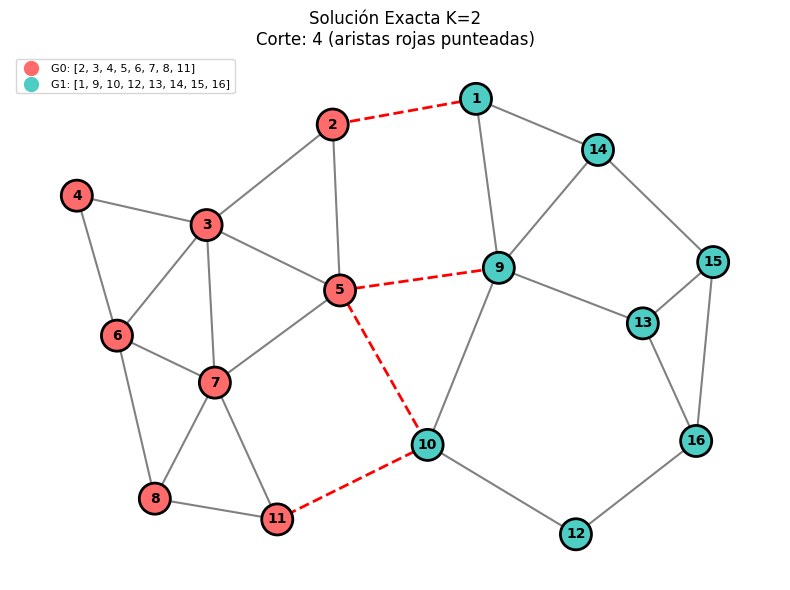

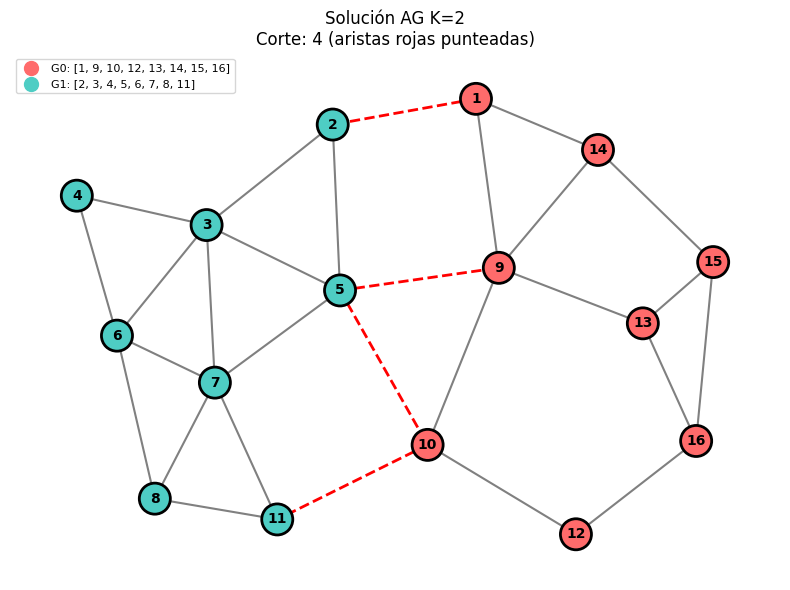

In [150]:
import networkx as nx

def graficar_particion(ind, k, titulo):
    G = nx.Graph()
    G.add_nodes_from(V)
    G.add_edges_from(E)
    
    colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F']
    color_nodos = [colores[ind[i]] for i in range(len(V))]
    
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    
    # Dibujar aristas (grises para internas, rojas para corte)
    aristas_internas = [(u,v) for u,v in E if ind[u-1] == ind[v-1]]
    aristas_corte_lista = [(u,v) for u,v in E if ind[u-1] != ind[v-1]]
    
    nx.draw_networkx_edges(G, pos, edgelist=aristas_internas, edge_color='gray', width=1.5)
    nx.draw_networkx_edges(G, pos, edgelist=aristas_corte_lista, edge_color='red', width=2, style='dashed')
    
    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color=color_nodos, node_size=500, edgecolors='black', linewidths=2)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    
    # Leyenda
    for g in range(k):
        nodos_g = [V[i] for i,x in enumerate(ind) if x==g]
        plt.scatter([], [], c=colores[g], s=100, label=f'G{g}: {nodos_g}')
    
    plt.legend(loc='upper left', fontsize=8)
    plt.title(f'{titulo}\nCorte: {corte(ind)} (aristas rojas punteadas)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Graficar resultados
for K in [2]:
    random.seed(42)
    ind_ex, c_ex, t_ex = exacto(K)
    ind_ag, c_ag, t_ag, *_ = ag(K)
    graficar_particion(ind_ex, K, f'Solución Exacta K={K}')
    graficar_particion(ind_ag, K, f'Solución AG K={K}')